<h3><center>Does having Ballon d'Or players increase a nation's chance of winning the World Cup,
or does winning the World Cup increase a player's chance of receiving Ballon d'Or votes?</center> </h3>

-----------------------------------------------------------------------------------------------------------------------

<li>Ballon d'Or & World Cup – Datenanalyse</li>

In [112]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import  mannwhitneyu
from scipy.stats import  fisher_exact

<li>Load data from csv files</li>


In [ ]:
players = pd.read_csv("players.csv")
ballondor = pd.read_csv("ballondor_all_ranked.csv")
standing = pd.read_csv("tournament_standings_2.csv")
matches_players = pd.read_csv("player_appearances.csv")

<li>Restructure the bd3 tabel</li>

<li>Resturcture the second ballondor dataset in the same way</li>

<li>Combine both ballondor datasets</li>

<li>Show the first 10 entries of each tabel</li>

In [114]:
#players.head()


In [115]:
#ballondor_combined.head()

In [116]:
#standing.head()

In [117]:
#matches_players.head()

<ol>
<li>Filter for Men's worldcup due to tabel containing Womens worldcup as well</li>
<li>Filter out the woldcup years</li>
<li>Converting "Years" of the ballondor set into an integer</li>
</ol>
<br>
<li>Print out the Number of Wolrdcups considerd in this analysis</li>

In [118]:

wc_standings = standing[standing["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)].copy()
wc_matches_players = matches_players[matches_players["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)].copy()

wc_standings["year"] = wc_standings["tournament_name"].str.extract(r"(\d{4})").astype(int)
wc_matches_players["year"] = wc_matches_players["tournament_name"].str.extract(r"(\d{4})").astype(int)

ballondor["Year"] = ballondor["Year"].astype(int)

print(f"Number of World Cups we consider: ")
print((len(wc_standings)/4))


Number of World Cups we consider: 
14.0


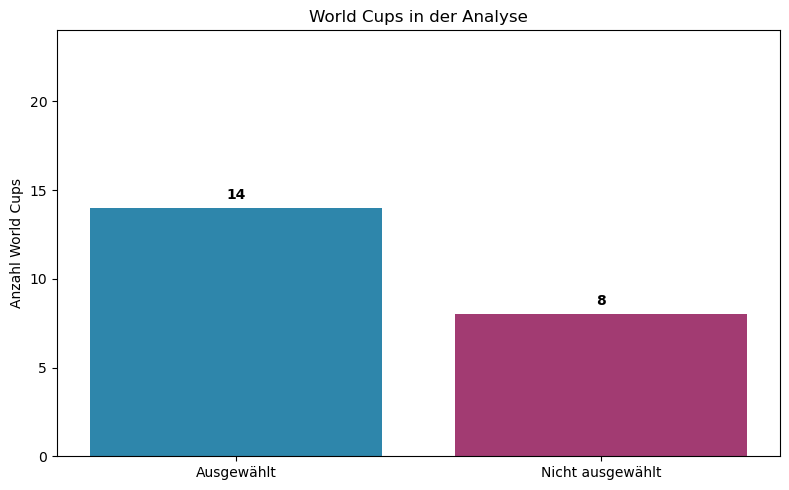

In [119]:
import matplotlib.pyplot as plt

total_wcs = len(wc_standings) / 4  # 14
all_wcs_ever = 22  # oder wie viele es insgesamt gibt

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Ausgewählt', 'Nicht ausgewählt'], 
       [total_wcs, all_wcs_ever - total_wcs],
       color=['#2E86AB', '#A23B72'])
ax.set_ylabel('Anzahl World Cups')
ax.set_title('World Cups in der Analyse')
ax.set_ylim(0, all_wcs_ever + 2)

# Werte auf den Balken anzeigen
for i, v in enumerate([total_wcs, all_wcs_ever - total_wcs]):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

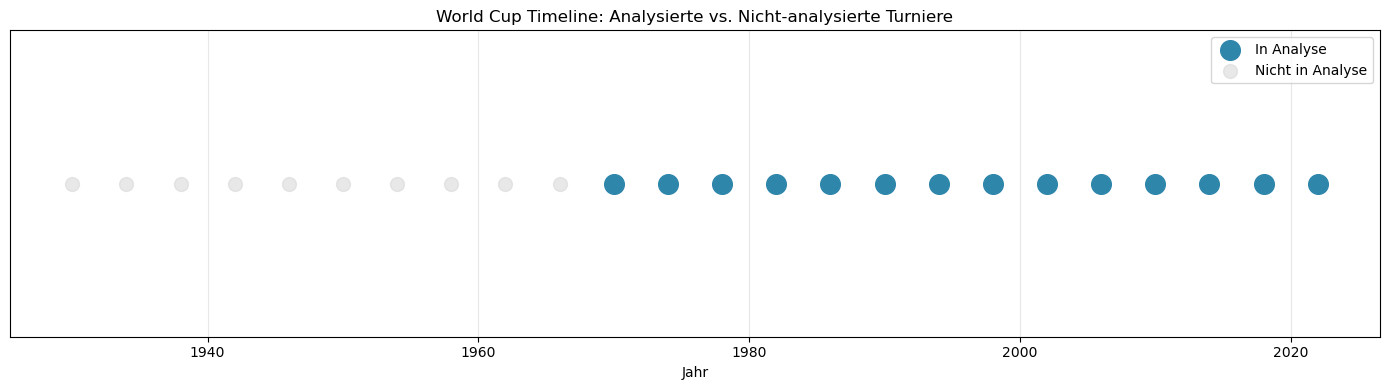

Analysierte Jahre: [1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
Number of total World Cups considers: 14


In [120]:
unique_years = sorted(wc_standings["year"].unique())
all_wc_years = list(range(1930, 2023, 4))  # Beispiel: alle 4 Jahre

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(unique_years, [1]*len(unique_years), s=200, c='#2E86AB', 
           label='In Analyse', zorder=3)
ax.scatter([y for y in all_wc_years if y not in unique_years], 
           [1]*len([y for y in all_wc_years if y not in unique_years]), 
           s=100, c='lightgray', label='Nicht in Analyse', alpha=0.5, zorder=2)

ax.set_yticks([])
ax.set_xlabel('Jahr')
ax.set_title('World Cup Timeline: Analysierte vs. Nicht-analysierte Turniere')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Analysierte Jahre: {[int(year) for year in unique_years]}")
print(f"Number of total World Cups considers: {len(unique_years)}")

<li>Just printing the years of the cup with the amount of teams in the standing tabel (always 4 becaus standing.csv has 4 entries for each tournament)</li>

In [121]:
#wc_standings["year"].value_counts().sort_index()


<li>Unify the player names of both list wc_matches_players and ballondor. <br>
For wc_matches_player append both names together.</li>

In [122]:

wc_matches_players["player_fullname"] = (
    wc_matches_players["given_name"].fillna("") + " " + wc_matches_players["family_name"].fillna("")
).str.strip().str.lower()


ballondor["player_fullname"] = ballondor["Player"].str.strip().str.lower()


<li>Print the first 10 entries of both tabel colums "player_fullname"</li>

In [123]:
print(ballondor["player_fullname"].head(10))
print(wc_matches_players["player_fullname"].head(10))

0          gerd müller
1          bobby moore
2            gigi riva
3    franz beckenbauer
4     wolfgang overath
5        dragan dzajic
6         johan cryuff
7         gordon banks
8       sandro mazzola
9         rinus israel
Name: player_fullname, dtype: object
0         ignacio calderón
1             gustavo peña
2              mario pérez
3      guillermo hernández
4    horacio lópez salgado
5            josé vantolrá
6            javier guzmán
7            héctor pulido
8            mario velarde
9          javier valdivia
Name: player_fullname, dtype: object


<li>Check for duplicates</li>

In [124]:
wc_matches_players["player_fullname"].nunique(), len(wc_matches_players)

(5079, 20618)

In [125]:
ballondor["player_fullname"].nunique(), len(ballondor)

(389, 810)

<li>Get rid of duplicates and make every entry for player in tournament unique.<br>
<u>Important:</u> One player has more than one appereance in the same WC tournament. We only need one of his entries and not all so make it unique</li>

In [126]:

unique_players = (
    wc_matches_players
    .groupby(["year", "player_id", "player_fullname", "team_id", "team_name"], as_index=False)
    .size()  
)

unique_players.head()


,year,player_id,player_fullname,team_id,team_name,size
0,1970,P-00086,roberto rivas,T-27,El Salvador,3
1,1970,P-00119,gigi riva,T-41,Italy,6
2,1970,P-00746,tom turesson,T-74,Sweden,2
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4


<li>Merge WM players and ballondor candidates of the same year.<br>
With this merge we link each WM Player with the ballondor ranking of that same year<br>
Resulting tabel gives information, if the player has been bd candidate or winner in the year of the wc and the year and rank.</li>

In [127]:
players_bd_same = unique_players.merge(
    ballondor[["Year", "player_fullname", "Rank"]],
    how="left",
    left_on=["year", "player_fullname"],
    right_on=["Year", "player_fullname"],
    suffixes=("", "_bd_same")
)

players_bd_same["is_bd_candidate_same_year"] = (players_bd_same["Rank"] <= 3).astype(int)
players_bd_same["is_bd_winner_same_year"] = (players_bd_same["Rank"] == 1).astype(int)

players_bd_same.head()

,year,player_id,player_fullname,team_id,team_name,size,Year,Rank,is_bd_candidate_same_year,is_bd_winner_same_year
0,1970,P-00086,roberto rivas,T-27,El Salvador,3,NaN,NaN,0,0
1,1970,P-00119,gigi riva,T-41,Italy,6,1970.0,3.0,1,0
2,1970,P-00746,tom turesson,T-74,Sweden,2,NaN,NaN,0,0
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2,NaN,NaN,0,0
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4,NaN,NaN,0,0


In [128]:

players_bd_same15 = unique_players.merge(
    ballondor[["Year", "player_fullname", "Rank"]],
    how="left",
    left_on=["year", "player_fullname"],
    right_on=["Year", "player_fullname"],
    suffixes=("", "_bd_same")
)

players_bd_same15["is_bd_candidate_same_year"] = (players_bd_same["Rank"] <= 15).astype(int)
players_bd_same15["is_bd_winner_same_year"] = (players_bd_same["Rank"] == 1).astype(int)

players_bd_same.head()

,year,player_id,player_fullname,team_id,team_name,size,Year,Rank,is_bd_candidate_same_year,is_bd_winner_same_year
0,1970,P-00086,roberto rivas,T-27,El Salvador,3,NaN,NaN,0,0
1,1970,P-00119,gigi riva,T-41,Italy,6,1970.0,3.0,1,0
2,1970,P-00746,tom turesson,T-74,Sweden,2,NaN,NaN,0,0
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2,NaN,NaN,0,0
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4,NaN,NaN,0,0


<li>Same as before but only for the one year befor the world cup to look for the second Hypotheses.<br>
We want to look if the ballondor winner of the previous year has an influence on the world cup winner.</li>

In [129]:
unique_players["year_minus_1"] = unique_players["year"] - 1

players_bd_before = unique_players.merge(
    ballondor[["Year", "player_fullname", "Rank"]],
    how="left",
    left_on=["year_minus_1", "player_fullname"],
    right_on=["Year", "player_fullname"],
    suffixes=("", "_bd_before")
)

players_bd_before["is_bd_candidate_before"] = (players_bd_before["Rank"] <= 3).astype(int)
players_bd_before["is_bd_winner_before"] = (players_bd_before["Rank"] == 1).astype(int)

players_bd_before.head()


,year,player_id,player_fullname,team_id,team_name,size,year_minus_1,Year,Rank,is_bd_candidate_before,is_bd_winner_before
0,1970,P-00086,roberto rivas,T-27,El Salvador,3,1969,NaN,NaN,0,0
1,1970,P-00119,gigi riva,T-41,Italy,6,1969,NaN,NaN,0,0
2,1970,P-00746,tom turesson,T-74,Sweden,2,1969,NaN,NaN,0,0
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2,1969,NaN,NaN,0,0
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4,1969,NaN,NaN,0,0


<li>Define variable to store wc standings without duplicates</li>

In [130]:
team_info = wc_standings[["year", "team_id", "team_name", "team_code", "position"]].drop_duplicates()
team_info.head(10)

,year,team_id,team_name,team_code,position
0,1970,T-09,Brazil,BRA,1
1,1970,T-41,Italy,ITA,2
2,1970,T-86,West Germany,DEU,3
3,1970,T-84,Uruguay,URY,4
4,1974,T-86,West Germany,DEU,1
5,1974,T-48,Netherlands,NLD,2
6,1974,T-57,Poland,POL,3
7,1974,T-09,Brazil,BRA,4
8,1978,T-03,Argentina,ARG,1
9,1978,T-48,Netherlands,NLD,2


<li>Add wc team rank from team info to the player of tabel player_bd_same.<br>
We match players ot their teams by year, team id und team_name.<br>
In this way we can check if the players wc rank has influence of ballondor ranking.</li>

In [131]:
players_bd_same = players_bd_same.merge(
    team_info[["year", "team_id", "team_name", "position"]].drop_duplicates(),
    on=["year", "team_id", "team_name"],
    how="left"
)

<li>Create new column to store if wc winner = 1 or not = 0</li>

In [132]:
players_bd_same["is_worldcup_winner_team"] = (players_bd_same["position"] == 1).astype(int)
print(players_bd_same["is_worldcup_winner_team"].head(10))


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    1
Name: is_worldcup_winner_team, dtype: int64


<li>Create tabel bd_ranks.<br>
Get all players that have a Ballondor ranking in the WC year and therefore are in the Top 3.<br>
Get the variable to show if the player is a wc winner of the same year.</li>

In [133]:
bd_ranks = players_bd_same.loc[
    players_bd_same["Rank"].notna(),
    ["Rank", "is_worldcup_winner_team"]
].copy()

bd_ranks["Rank"] = bd_ranks["Rank"].astype(int)
bd_ranks["is_worldcup_winner_team"] = bd_ranks["is_worldcup_winner_team"].astype(int)

bd_ranks.head()
players_bd_same.groupby("year")["is_bd_candidate_same_year"].sum()

year
1970    3
1974    3
1978    2
1982    3
1986    2
1990    3
1994    3
1998    2
2002    2
2006    3
2010    2
2014    3
2018    3
2022    1
Name: is_bd_candidate_same_year, dtype: int64

<li>Count how many ballondor candidates each wc year has had.</li>

In [134]:
players_bd_same.groupby("year")["is_bd_candidate_same_year"].sum()


year
1970    3
1974    3
1978    2
1982    3
1986    2
1990    3
1994    3
1998    2
2002    2
2006    3
2010    2
2014    3
2018    3
2022    1
Name: is_bd_candidate_same_year, dtype: int64

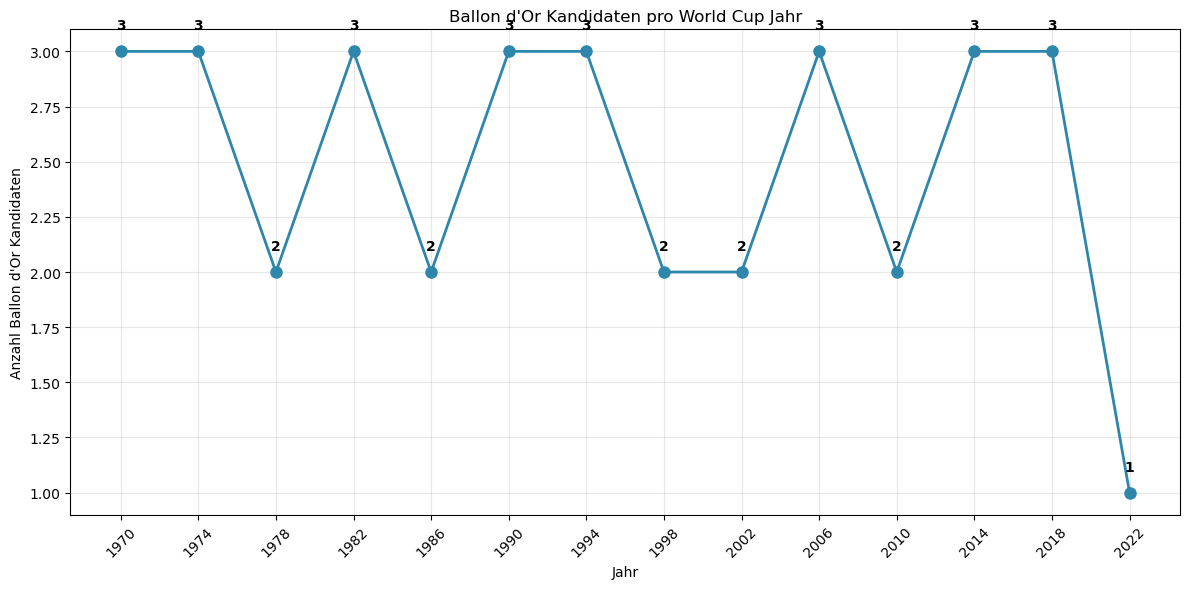

In [135]:
import matplotlib.pyplot as plt

candidate_counts = players_bd_same.groupby("year")["is_bd_candidate_same_year"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(candidate_counts.index, candidate_counts.values, marker='o', 
        linewidth=2, markersize=8, color='#2E86AB')
ax.set_xlabel('Jahr')
ax.set_ylabel('Anzahl Ballon d\'Or Kandidaten')
ax.set_title('Ballon d\'Or Kandidaten pro World Cup Jahr')
ax.grid(True, alpha=0.3)
ax.set_xticks(candidate_counts.index)
ax.set_xticklabels(candidate_counts.index, rotation=45)

# Werte über den Punkten anzeigen
for year, count in candidate_counts.items():
    ax.text(year, count + 0.1, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [136]:
players_bd_before.groupby("year")["is_bd_candidate_before"].sum()


year
1970    0
1974    3
1978    1
1982    2
1986    1
1990    3
1994    2
1998    2
2002    2
2006    2
2010    2
2014    2
2018    2
2022    2
Name: is_bd_candidate_before, dtype: int64

-----------------------------------------------------------------------------------------------------------------------


This block aggregates player-level information into team-level statistics
for each World Cup year. After merging player data with team placements,
we compute: <br>

<ul>
    <li>number of players per team (`num_players`)</li>
    <li>number and presence of Ballon d'Or candidates from the previous year</li>
    <li>number and presence of Ballon d'Or winners from the previous year</li>
    <li>final World Cup placement (`position`)</li>
    <li>whether the team became World Cup champion (`is_worldcup_winner`)</li>
</ul>



In [137]:
team_summary_before = (
    players_bd_before
    .merge(team_info, on=["year", "team_id", "team_name"], how="left")
    .groupby(["year", "team_id", "team_name", "team_code"], as_index=False)
    .agg(
        num_players                  = ("player_id", "nunique"),
        num_bd_candidates_before     = ("is_bd_candidate_before", "sum"),
        has_bd_candidate_before      = ("is_bd_candidate_before", lambda x: x.any()),
        num_bd_winners_before        = ("is_bd_winner_before", "sum"),
        has_bd_winner_before         = ("is_bd_winner_before", lambda x: x.any()),
        position                     = ("position", "first")  
    )
)

team_summary_before["is_worldcup_winner"] = (team_summary_before["position"] == 1).astype(int)

team_summary_before.tail()
len(team_summary_before)


56

Same as done above just for Hypotheses 2:

In [138]:

team_summary_same = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(
        num_players            = ("player_id", "nunique"),
        num_bd_candidates_same = ("is_bd_candidate_same_year", "sum"),
        has_bd_candidate_same  = ("is_bd_candidate_same_year", lambda x: x.any()),
        num_bd_winners_same    = ("is_bd_winner_same_year", "sum"),
        has_bd_winner_same     = ("is_bd_winner_same_year", lambda x: x.any())
    )
)


team_summary_same = team_summary_same.merge(
    team_info[["year", "team_id", "position"]],
    on=["year", "team_id"],
    how="left"
)

team_summary_same["is_worldcup_winner"] = (team_summary_same["position"] == 1).astype(int)

team_summary_same.tail()
len(team_summary_same)


368

<li>Groupby years to see for the years befor wc how many ballondor candidates there have been and how many winners</li>

In [139]:
team_summary_before.groupby("year")[["num_bd_candidates_before", "num_bd_winners_before"]].sum()

,num_bd_candidates_before,num_bd_winners_before
year,,
1970,0,0
1974,2,1
1978,0,0
1982,2,1
1986,1,1
1990,1,0
1994,1,1
1998,1,0
2002,1,0


<li>Groupby years to see how mand ballondor candidates and winners in the same year as wc there are</li>

In [140]:
team_summary_same.groupby("year")[["num_bd_candidates_same", "num_bd_winners_same"]].sum()


,num_bd_candidates_same,num_bd_winners_same
year,,
1970,3,1
1974,3,1
1978,2,0
1982,3,1
1986,2,0
1990,3,1
1994,3,1
1998,2,1
2002,2,0


-----------------------------------------------------------------------------------------------------------------------

<h2><center>Deskriptiv Statistics</center></h2>

In [141]:
n_world_cups = team_summary_before[team_summary_before["is_worldcup_winner"] == 1].shape[0]

# Time range
min_year = team_summary_before["year"].min()
max_year = team_summary_before["year"].max()

print("Dataset Overview")
print("----------------")
print(f"World Cups analyzed: {n_world_cups}")
print(f"Year range: {min_year}–{max_year}")

Dataset Overview
----------------
World Cups analyzed: 14
Year range: 1970–2022


<center>Kontingenztafel</center>

In [142]:
contingency_table = pd.crosstab(
    team_summary_before["is_worldcup_winner"],
    team_summary_before["has_bd_winner_before"],
    rownames=["World Cup Winner"],
    colnames=["Has Ballon d'Or Winner Before"]
)

print("\nContingency Table")
print("-----------------")
print(contingency_table)


Contingency Table
-----------------
Has Ballon d'Or Winner Before  False  True 
World Cup Winner                           
0                                 38      4
1                                 13      1


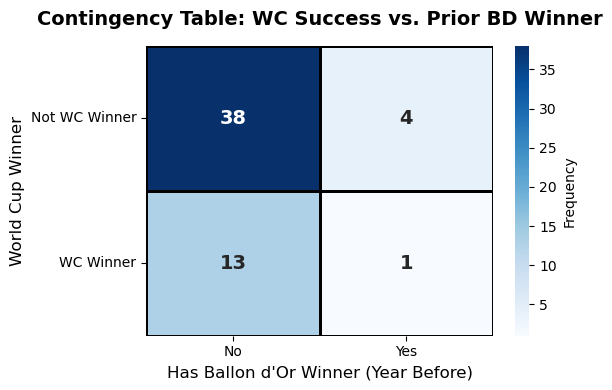

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kontingenztabelle
fig, ax = plt.subplots(figsize=(6, 4))

# Heatmap mit Annotationen
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Frequency'}, linewidths=2, 
            linecolor='black', ax=ax, annot_kws={'fontsize': 14, 'fontweight': 'bold'})

ax.set_title('Contingency Table: WC Success vs. Prior BD Winner', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Has Ballon d\'Or Winner (Year Before)', fontsize=12)
ax.set_ylabel('World Cup Winner', fontsize=12)

# Y-Achse lesbarer machen
ax.set_yticklabels(['Not WC Winner', 'WC Winner'], rotation=0)
ax.set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.savefig('heatmap_rq1.pdf', dpi=300, bbox_inches='tight')
plt.show()

-----------------------------------------------------------------------------------------------------------------------

<center>Ballondor Statistics</center>

-----------------------------------------------------------------------------------------------------------------------

<h4><center>Test's</center></h4>

Hypothesis 1: <br>
BD candidates in the previous year → influence on WM win?<br>

Construct a 2x2 matrix tabel to compare possibilitys:

<ul> 
    <li>is_woldcup_winner = 1 → has won wc</li>
    <li>has_bd_winner_before = 1 → has won bd year before wc</li>
</ul>
<br>
This shows how often the winning team has a ballondor winner in their team and how often not and of there is even a correlation.<br>
Apply Fishers Exact Test to determin the statistical significance assosiated between the 2 variables.



In [144]:
cont_before = pd.crosstab(
    team_summary_before["is_worldcup_winner"],
    team_summary_before["has_bd_winner_before"]
)

print("Kontingenztafel  Vorjahres BD-Gewinner vs WM-Sieg:")
print(cont_before)

oddsratio_before, p_before = fisher_exact(cont_before)
print("Fisher Exact Test  befor:")
print("Odds Ratio:", oddsratio_before)
print("p-Value:", p_before)

Kontingenztafel  Vorjahres BD-Gewinner vs WM-Sieg:
has_bd_winner_before  False  True 
is_worldcup_winner                
0                        38      4
1                        13      1
Fisher Exact Test  befor:
Odds Ratio: 0.7307692307692307
p-Value: 1.0


-----------------------------------------------------------------------------------------------------------------------

Hypothesis 2:<br>
WM win → Better Ballon d’Or ranking in the same year?<br>
Prep ballndor data set<br>

First create a colum to have a binary value to check if the player is wc winner.<br>
Then extract players how have a ranking in ballondor of the year of wc.<br>
Therefor we only use two Variables "Rank" and "is_worldcup_winner"<br>



In [145]:
players_bd_same["is_worldcup_winner_team"] = (players_bd_same["position"] == 1).astype(int)

bd_ranks = players_bd_same.loc[
    players_bd_same["Rank"].notna(),
    ["Rank", "is_worldcup_winner_team"]
].copy()

bd_ranks["Rank"] = bd_ranks["Rank"].astype(int)
bd_ranks["is_worldcup_winner_team"] = bd_ranks["is_worldcup_winner_team"].astype(int)

bd_ranks.head()


,Rank,is_worldcup_winner_team
1,3,0
73,13,0
137,2,0
160,5,0
165,11,0


Spliting ballondor ranked players it the two groups where one is the winner of wc and the rest in a dfferent group. <br>
These two distributions are required for the Mann–Whitney U test, which examines
whether players from World Cup winning teams achieve significantly better/lower Ballon d'Or rankings in the same year

In [146]:
winner_ranks = bd_ranks[bd_ranks["is_worldcup_winner_team"] == 1]["Rank"]
other_ranks  = bd_ranks[bd_ranks["is_worldcup_winner_team"] == 0]["Rank"]


Convert to integer

In [147]:
winner_ranks = winner_ranks.astype(int)
other_ranks  = other_ranks.astype(int)

In [148]:

stat, p = mannwhitneyu(winner_ranks, other_ranks, alternative="two-sided")
print("Mann-Whitney U:", stat)
print("p-Wert:", p)


Mann-Whitney U: 2216.0
p-Wert: 0.39223829988645753


-----------------------------------------------------------------------------------------------------------------------

Permutationstest


In [149]:
observed_diff = (
    bd_ranks.loc[bd_ranks["is_worldcup_winner_team"] == 1, "Rank"].median()
    - bd_ranks.loc[bd_ranks["is_worldcup_winner_team"] == 0, "Rank"].median()
)

observed_diff


-1.0

In [150]:
import numpy as np

n_perm = 10000
perm_diffs = []

for _ in range(n_perm):
    shuffled = bd_ranks["is_worldcup_winner_team"].sample(frac=1, replace=False).values
    perm_diff = (
        bd_ranks.loc[shuffled == 1, "Rank"].median()
        - bd_ranks.loc[shuffled == 0, "Rank"].median()
    )
    perm_diffs.append(perm_diff)

perm_diffs = np.array(perm_diffs)


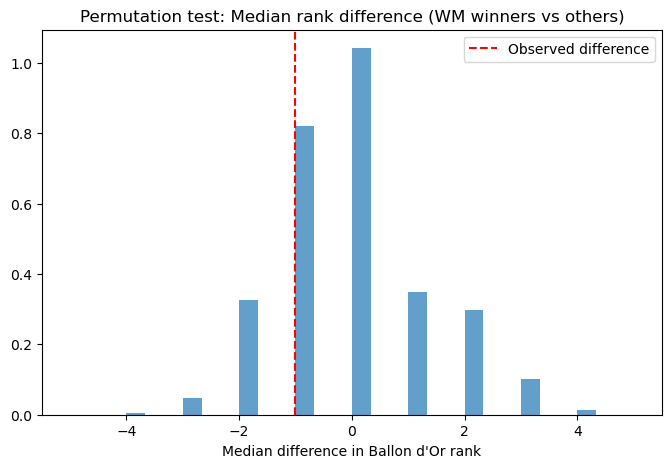

In [151]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(perm_diffs, bins=30, density=True, alpha=0.7)
ax.axvline(observed_diff, color="red", linestyle="--", label="Observed difference")
ax.set_title("Permutation test: Median rank difference (WM winners vs others)")
ax.set_xlabel("Median difference in Ballon d'Or rank")
ax.legend()
plt.show()


-----------------------------------------------------------------------------------------------------------------------

Cliffs Delta für die effektgröße.


In [152]:

def cliffs_delta(x, y):
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    return (gt - lt) / (len(x) * len(y))

x = winner_ranks.to_numpy()
y = other_ranks.to_numpy()

delta = cliffs_delta(x, y)
print("Delta value:", delta)

Delta value: -0.09087179487179488


In [153]:
def bootstrap_cliffs_delta(x, y, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    deltas = np.empty(n_boot)
    for b in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        deltas[b] = cliffs_delta(xb, yb)
    ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])
    return ci_low, ci_high

ci_low, ci_high = bootstrap_cliffs_delta(x, y, n_boot=10000, seed=42)
print(f"Lower bound: {ci_low}, Higher bound {ci_high}")


Lower bound: -0.3021589743589744, Higher bound 0.11898461538461523


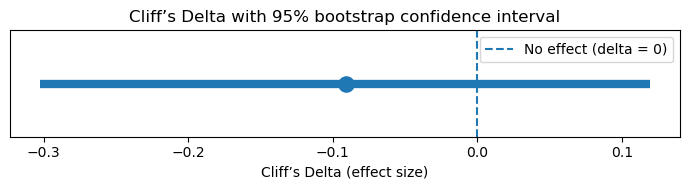

In [154]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 2))

# CI als dicker Balken
ax.hlines(y=0, xmin=ci_low, xmax=ci_high, linewidth=6)

# Punkt = Effektgröße
ax.scatter(delta, 0, s=120, zorder=3)

# Referenz: kein Effekt
ax.axvline(0, linestyle="--", label="No effect (delta = 0)")

ax.set_yticks([])
ax.set_xlabel("Cliff’s Delta (effect size)")
ax.set_title("Cliff’s Delta with 95% bootstrap confidence interval")
ax.legend()
plt.tight_layout()
plt.show()


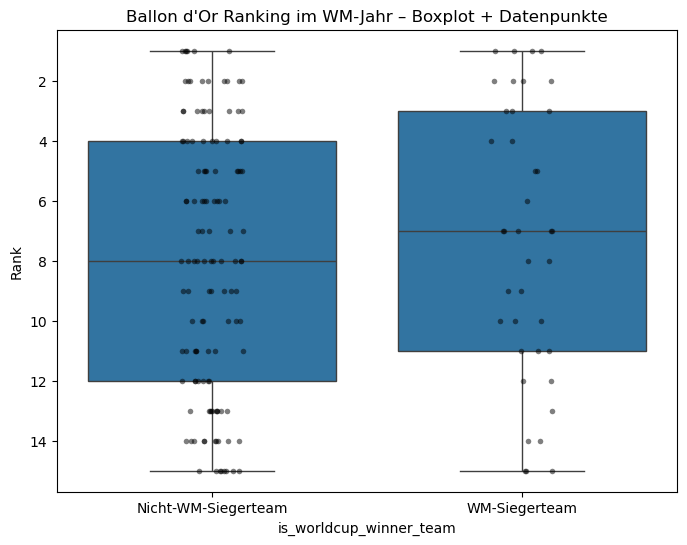

In [157]:
plt.figure(figsize=(8,6))
sns.boxplot(data=bd_ranks, x="is_worldcup_winner_team", y="Rank", showfliers=False)
sns.stripplot(data=bd_ranks, x="is_worldcup_winner_team", y="Rank", color="black", size=4, alpha=0.5)
plt.gca().invert_yaxis()
plt.xticks([0, 1], ["Nicht-WM-Siegerteam", "WM-Siegerteam"])
plt.title("Ballon d'Or Ranking im WM-Jahr – Boxplot + Datenpunkte")
plt.show()


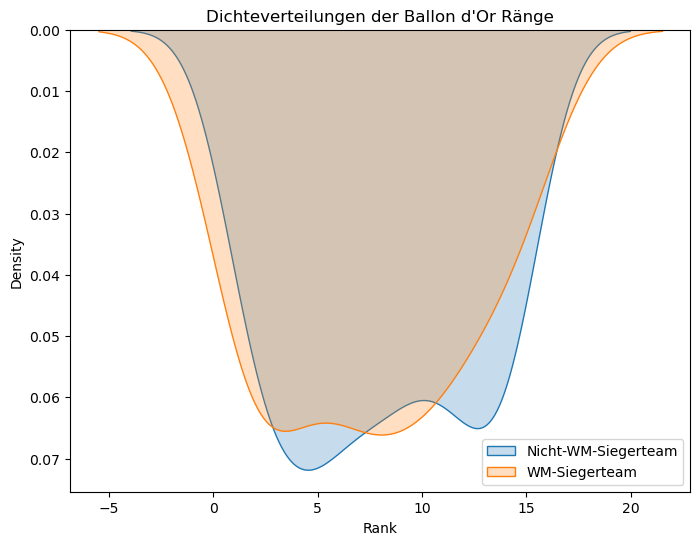

In [158]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=bd_ranks[bd_ranks["is_worldcup_winner_team"] == 0]["Rank"], label="Nicht-WM-Siegerteam", fill=True)
sns.kdeplot(data=bd_ranks[bd_ranks["is_worldcup_winner_team"] == 1]["Rank"], label="WM-Siegerteam", fill=True)
plt.gca().invert_yaxis()
plt.title("Dichteverteilungen der Ballon d'Or Ränge")
plt.legend()
plt.show()


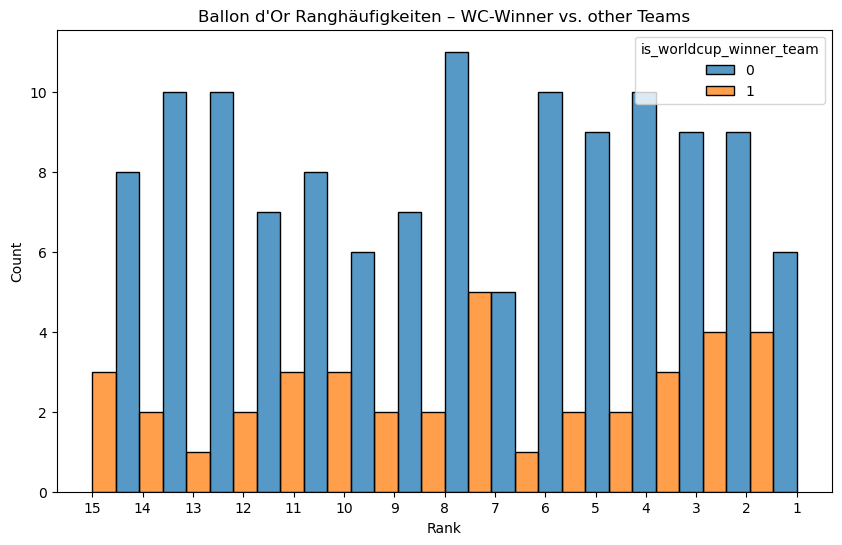

In [195]:
plt.figure(figsize=(10,6))
sns.histplot(bd_ranks, x="Rank", hue="is_worldcup_winner_team", multiple="dodge", bins=15)
plt.gca().invert_xaxis()
plt.title("Ballon d'Or Ranghäufigkeiten – WC-Winner vs. other Teams")
plt.xticks(range(1, 16))
plt.show()


-----------------------------------------------------------------------------------------------------------------------

<Center>Hypotheses 1</Center><br>

-----------------------------------------------------------------------------------------------------------------------

<li>Fischers Exact test for the Top 3 instad only looking for the Ballondor Winner</li>

In [166]:
players_bd_same["is_top3"] = (players_bd_same["Rank"] <= 3).astype(int)

In [161]:
team_top3 = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top3_player=("is_top3", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top3["is_worldcup_winner"] = (team_top3["position"] == 1).astype(int)


In [184]:

cont_top3 = pd.crosstab(
    team_top3["is_worldcup_winner"],
    team_top3["has_top3_player"]
)

odds_top3, p_top3 = fisher_exact(cont_top3)
print(f"p-value: {p_top3}")
print(odds_top3)
print(cont_top3)


p-value: 0.11712917019150512
3.24
has_top3_player     False  True 
is_worldcup_winner              
0                      27     15
1                       5      9


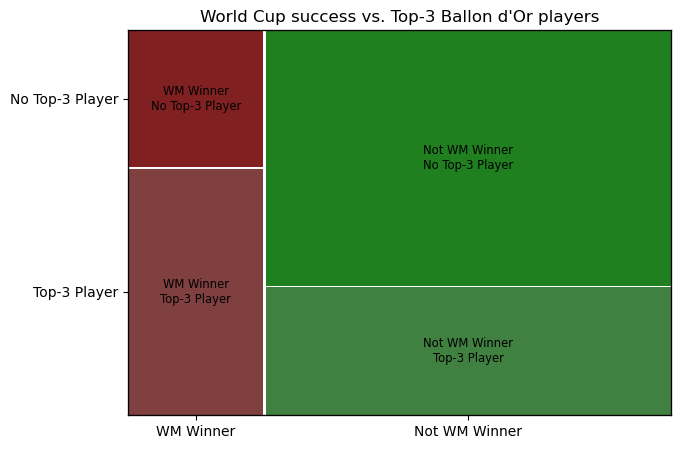

In [ ]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt

# Daten vorbereiten
mosaic_data = {
    ("WM Winner", "Top-3 Player"): 9,
    ("WM Winner", "No Top-3 Player"): 5,
    ("Not WM Winner", "Top-3 Player"): 14,
    ("Not WM Winner", "No Top-3 Player"): 28,
}

fig, ax = plt.subplots(figsize=(7,5))
mosaic(mosaic_data, ax=ax)

ax.set_title("World Cup success vs. Top-3 Ballon d'Or players")
plt.show()


--------------------------------------------------------------------------------------------------------------

<center>Top 10</center>

In [189]:
players_bd_same["is_top10"] = (players_bd_same["Rank"] <= 10).astype(int)


In [190]:
team_top10 = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top10_player=("is_top10", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top10["is_worldcup_winner"] = (team_top10["position"] == 1).astype(int)

In [192]:
cont_top10 = pd.crosstab(
    team_top10["is_worldcup_winner"],
    team_top10["has_top10_player"]
)

odds_top10, p_top10 = fisher_exact(cont_top10)
print(f"p-vlaue: {p_top10}")
print(odds_top10)
print(cont_top10)

p-vlaue: 0.7507955057389036
0.8068965517241379
has_top10_player    False  True 
is_worldcup_winner              
0                      13     29
1                       5      9


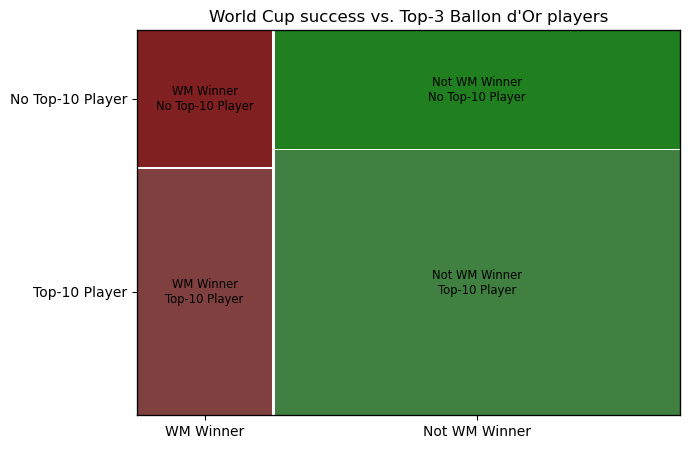

In [193]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt

# Daten vorbereiten
mosaic_data = {
    ("WM Winner", "Top-10 Player"): 9,
    ("WM Winner", "No Top-10 Player"): 5,
    ("Not WM Winner", "Top-10 Player"): 29,
    ("Not WM Winner", "No Top-10 Player"): 13,
}

fig, ax = plt.subplots(figsize=(7,5))
mosaic(mosaic_data, ax=ax)

ax.set_title("World Cup success vs. Top-3 Ballon d'Or players")
plt.show()


--------------------------------------------------------------------------------------------------------------

<center>Top 5</center>

In [185]:
players_bd_same["is_top5"] = (players_bd_same["Rank"] <= 5).astype(int)

In [186]:
team_top5 = (
    players_bd_same15
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top5_player=("is_top5", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top5["is_worldcup_winner"] = (team_top5["position"] == 1).astype(int)

In [188]:
cont_top5 = pd.crosstab(
    team_top5["is_worldcup_winner"],
    team_top5["has_top5_player"]
)

odds_top5, p_top5 = fisher_exact(cont_top5)
print(f"p-vlaue: {p_top5}")
print(odds_top5)
print(cont_top5)

p-vlaue: 0.5415585221513101
1.6363636363636365
has_top5_player     False  True 
is_worldcup_winner              
0                      20     22
1                       5      9


--------------------------------------------------------------------------------------------------------------

<center>Top 15</center>

In [176]:
players_bd_same15["is_top15"] = (players_bd_same["Rank"] <= 15).astype(int)

In [177]:
team_top15 = (
    players_bd_same15
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(has_top15_player=("is_top15", "any"))
    .merge(team_info[["year", "team_id", "position"]], on=["year", "team_id"])
)

team_top15["is_worldcup_winner"] = (team_top15["position"] == 1).astype(int)

In [194]:
cont_top15 = pd.crosstab(
    team_top15["is_worldcup_winner"],
    team_top15["has_top15_player"]
)

odds_top15, p_top15 = fisher_exact(cont_top15)
print(f"p-value: {p_top15}")
print(odds_top15)
print(cont_top15)

p-value: 0.3044765169480779
0.4909090909090909
has_top15_player    False  True 
is_worldcup_winner              
0                       9     33
1                       5      9
